
# Step 09 — Resolution sensitivity: does the rod split appear at the published granularity?

**Purpose.** Bise et al. clustered at **resolution 0.2** and obtained 17 clusters,
among them two rod populations with reciprocal paralog usage. The primary analysis
here clustered at **0.6** and tested those pairs by subclustering *within* an
annotated rod population — a different procedure, and one of the four candidate
explanations in §4.2 for why the split did not reproduce.

This notebook tests that explanation directly.

## Why this is a better comparison than the primary one

Their rod clusters A and B emerged from **global** clustering, not from
subclustering. Reproducing the procedure means clustering the whole dataset at 0.2
and asking whether two rod populations fall out — which is what this does.

Rod clusters are identified here from **marker expression**, not by carrying the
resolution-0.6 labels across. Carrying labels would impose the earlier partition on
the new one, and the question is precisely whether the new partition differs.

## What the two outcomes mean

- **The split appears** → clustering granularity explains the failure, and §3.10
  and §4.2 of the report need revising.
- **The split does not appear** → granularity is eliminated, alongside batch
  structure (§4.7), and normalisation remains the leading candidate.

Either way this is a sensitivity analysis; the resolution-0.6 result stays primary.

In [1]:
import sys
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").exists(), (
    f"Cannot locate the repository root from {Path.cwd()}. "
    "Launch JupyterLab from the repository root."
)
sys.path.insert(0, str(REPO_ROOT))

from scripts import config as cfg
from scripts import io_utils, qc, preprocessing, clustering, annotation, egfp_analysis, plotting

cfg.ensure_directories()
plotting.set_style()
SEED = io_utils.set_seeds()
print(f"Repository root: {REPO_ROOT}")
print(f"Random seed: {SEED}")

Repository root: D:\retina\project1_zebrafish_retina
Random seed: 0


In [2]:
import pandas as pd
from scripts import resolution_check as rc

adata = io_utils.load_checkpoint("annotated")
print(f"{adata.n_obs} cells, {adata.raw.n_vars} genes in .raw")

Loaded 'annotated': 15893 cells x 2000 genes
15893 cells, 22813 genes in .raw



## 1. Cluster at the published resolution

Only the community-detection step changes: the neighbour graph, embedding and
feature selection are reused, so any difference is attributable to resolution
alone.

In [3]:
adata = rc.cluster_at_resolution(adata, resolution=0.2)
KEY = "leiden_res_0.2"
print(adata.obs[KEY].value_counts().sort_index().to_string())

'leiden_res_0.2' already present; reusing it.
Resolution 0.2: 12 clusters (published analysis reported 17 at this resolution)
leiden_res_0.2
0     1894
1     2922
2     1540
3     3470
4     1709
5     1547
6      129
7      580
8      199
9      851
10    1001
11      51



### Interpretation

Compare the cluster count against the 17 reported by Bise et al. A close match
means the granularity is comparable and the test that follows is a fair one. A
large difference is itself worth reporting — the same nominal resolution does not
give the same partition across algorithms, since Leiden and Seurat's SNN optimise
different objectives.


## 2. Identify the rod clusters from markers

In [4]:
rod_clusters, marker_means = rc.identify_rod_clusters(adata, KEY)
rc.save_res_table(marker_means, "rod_marker_means_res02.csv")
display(marker_means)


Rod marker expression per cluster at this resolution:
                n_cells    rho   rhol  nr2e3  gnat1   sagb  pde6b
leiden_res_0.2                                                   
0                  1894  6.275  1.689  0.322  4.538  3.573  3.911
1                  2922  5.098  1.006  0.291  3.402  2.202  1.871
2                  1540  3.154  0.263  0.096  1.538  0.718  0.574
3                  3470  7.487  1.256  0.148  5.075  2.933  1.866
4                  1709  3.357  0.316  0.081  1.791  0.837  0.683
5                  1547  4.293  0.507  0.320  2.544  1.474  1.208
6                   129  3.180  0.177  0.057  1.510  0.653  0.546
7                   580  3.210  0.213  0.043  1.514  0.680  0.531
8                   199  4.500  0.335  0.077  2.222  0.828  0.499
9                   851  3.866  0.304  0.053  2.039  0.734  0.562
10                 1001  3.087  0.142  0.043  1.338  0.501  0.330
11                   51  3.612  0.334  0.046  1.469  0.635  0.547

rho ranges 3.09-7.49

,leiden_res_0.2,n_cells,rho,rhol,nr2e3,gnat1,sagb,pde6b
0,0,1894,6.275,1.689,0.322,4.538,3.573,3.911
1,1,2922,5.098,1.006,0.291,3.402,2.202,1.871
2,2,1540,3.154,0.263,0.096,1.538,0.718,0.574
3,3,3470,7.487,1.256,0.148,5.075,2.933,1.866
4,4,1709,3.357,0.316,0.081,1.791,0.837,0.683
5,5,1547,4.293,0.507,0.320,2.544,1.474,1.208
6,6,129,3.180,0.177,0.057,1.510,0.653,0.546
7,7,580,3.210,0.213,0.043,1.514,0.680,0.531
8,8,199,4.500,0.335,0.077,2.222,0.828,0.499
9,9,851,3.866,0.304,0.053,2.039,0.734,0.562



### Interpretation

**How many rod clusters emerged?** This is the first half of the question. The
published analysis found two. One means the two-population structure does not
arise at this resolution in these data, and the paralog test cannot be applied.
Two or more means the test is meaningful.

**Why selection is relative rather than absolute.** An absolute rho threshold does
not work in this dataset: rods dominate the tissue and lyse during dissociation, so
ambient rho contaminates every droplet and every cluster carries a substantial mean
— the same effect that made gene-set panel scores unusable in §2.6. Selection
therefore takes clusters above a quantile of the rho cluster means AND requires
*nr2e3*, a rod-specific transcription factor expressed at much lower absolute
levels and correspondingly less exposed to ambient contamination.

If the printed criterion selects every cluster, or a cluster you expect to be a rod
sits just outside, inspect the table and pass `min_rho=` explicitly — recording the
choice in the Methods.


## 3. The paralog test

The published result requires the three pairs to split in a **coordinated**
way: one cluster high in *rho*, *pde6ga* and *guca1a* together, another high in
*rhol*, *pde6gb* and *guca1b*. The per-cluster pattern printed below reads AAA for
the first arrangement and BBB for the second; the published structure would show
both.

In [5]:
paralogs, verdict = rc.paralog_test(adata, KEY, rod_clusters)
rc.save_res_table(paralogs, "paralogs_res02.csv")
display(paralogs)


Paralog expression across the 4 rod cluster(s):
                n_cells    rho   rhol  pde6ga  pde6gb  guca1a  guca1b
leiden_res_0.2                                                       
0                  1894  6.275  1.689   4.359   4.792   1.671   1.899
1                  2922  5.098  1.006   3.000   3.475   0.919   1.143
3                  3470  7.487  1.256   3.894   5.594   2.777   1.029
5                  1547  4.293  0.507   2.228   2.891   0.755   0.634

Inversion test:
  rho/rhol: rho > rhol in every cluster — no inversion
  pde6ga/pde6gb: pde6gb > pde6ga in every cluster — no inversion
  guca1a/guca1b: SPLIT across clusters — inversion present

1 of 3 pairs split.
A partial, discordant split — the same outcome as the primary analysis. Clustering granularity does not explain the failure.

Per-cluster pattern (A = rho/pde6ga/guca1a side, B = the paralog side):
cluster  n_cells pattern
      0     1894     ABB
      1     2922     ABB
      3     3470     ABA
      5     1547

,leiden_res_0.2,n_cells,rho,rhol,pde6ga,pde6gb,guca1a,guca1b
0,0,1894,6.275,1.689,4.359,4.792,1.671,1.899
1,1,2922,5.098,1.006,3.000,3.475,0.919,1.143
2,3,3470,7.487,1.256,3.894,5.594,2.777,1.029
3,5,1547,4.293,0.507,2.228,2.891,0.755,0.634



## 4. Compare against the primary analysis

Saved res_fig1_paralogs_by_resolution -> figures/resolution_check/


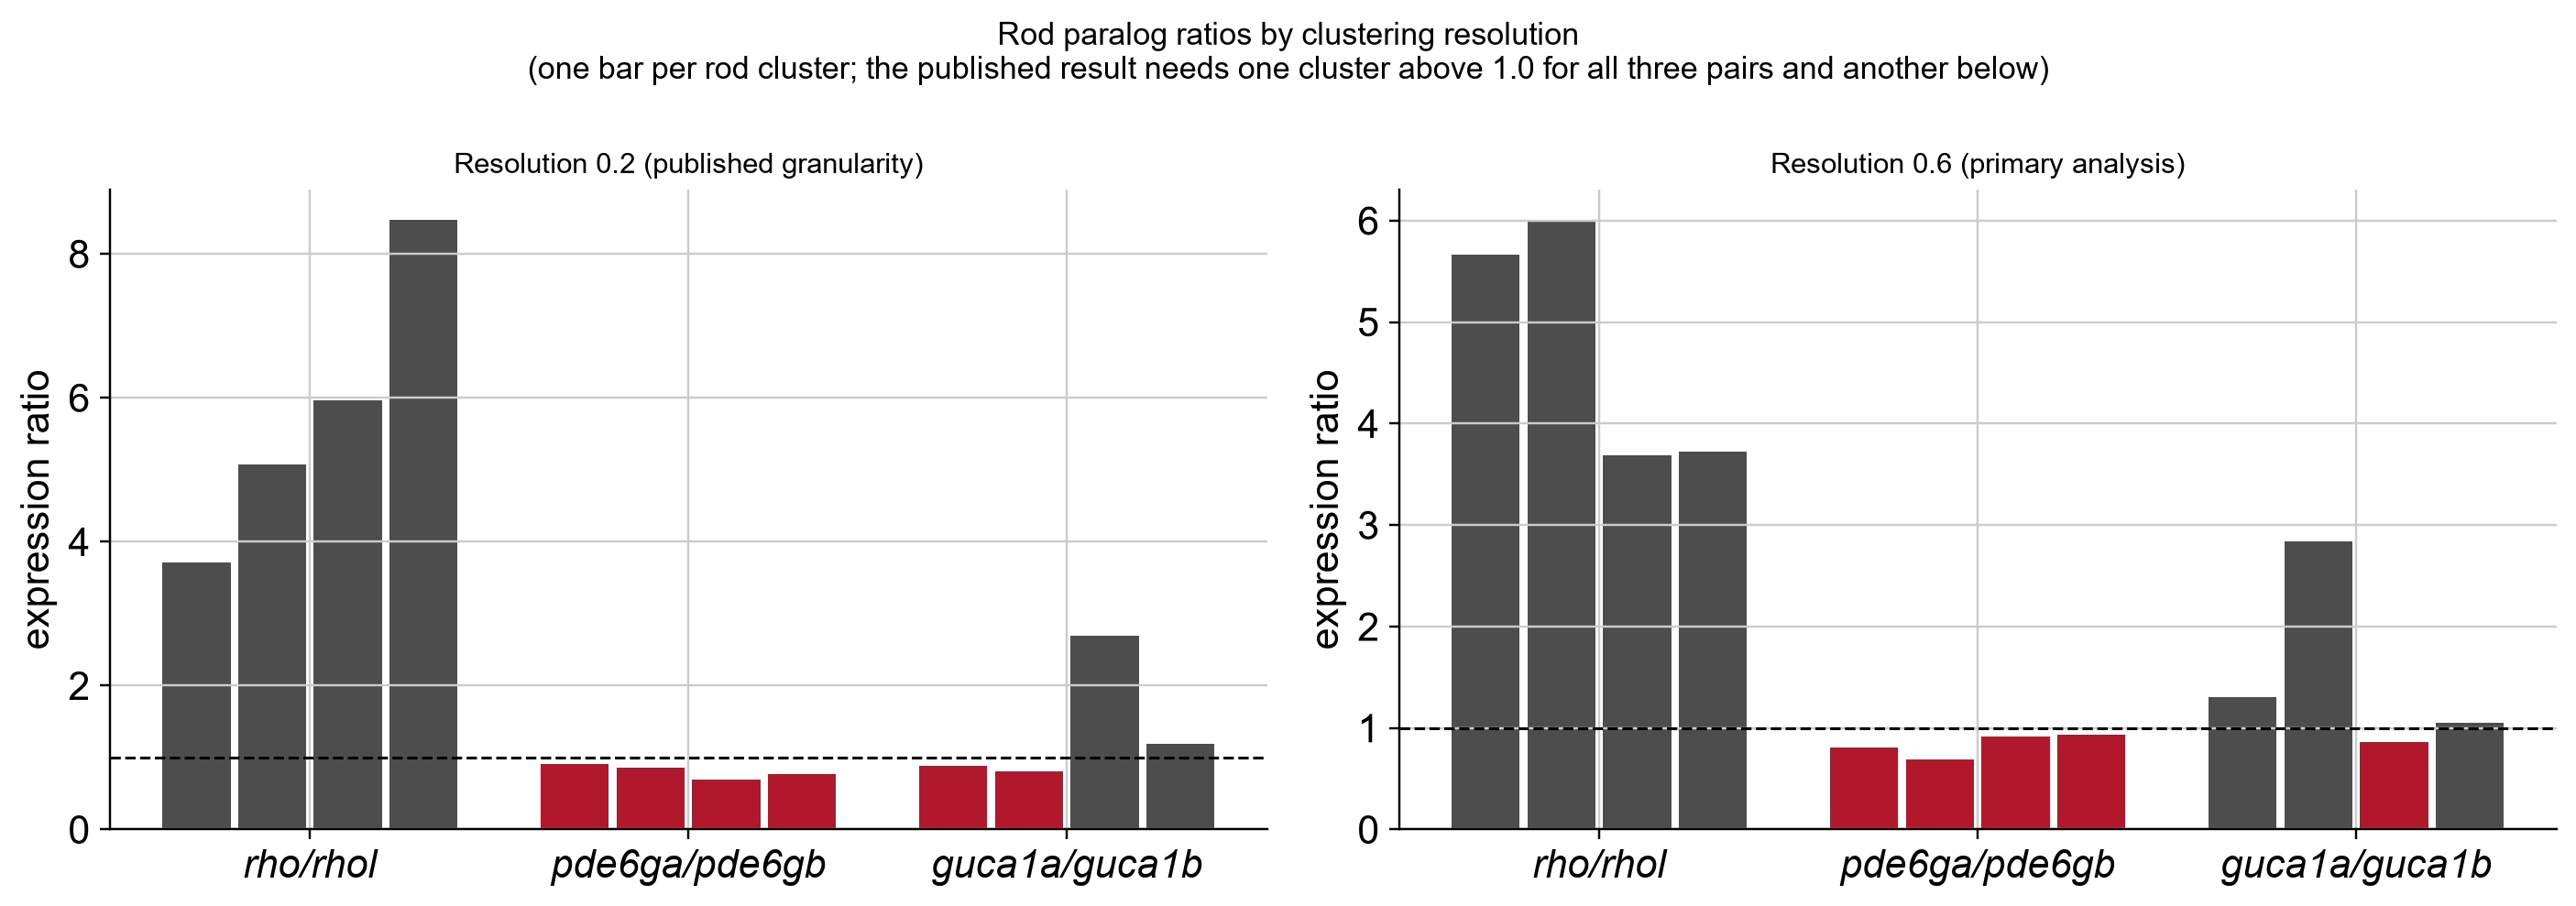

In [6]:
# The resolution-0.6 result, for the side-by-side figure.
prev = None
try:
    prev = pd.read_csv(cfg.TABLES_DIR / "rod_subcluster_evidence.csv")
    keep = [c for c in ["subcluster", "rho", "rhol", "pde6ga", "pde6gb",
                        "guca1a", "guca1b"] if c in prev.columns]
    prev = prev[keep]
except FileNotFoundError:
    print("rod_subcluster_evidence.csv not found; plotting resolution 0.2 alone.")

fig = rc.figure_resolution_comparison(paralogs, prev)


## 5. Summary

In [7]:
summary = rc.summarise(adata.obs[KEY].nunique(), rod_clusters, verdict)
rc.save_res_table(summary, "resolution_sensitivity_summary.csv")


RESOLUTION SENSITIVITY — SUMMARY
resolution                      0.2
n_clusters                       12
n_clusters_published             17
n_rod_clusters                    4
paralog_pairs_splitting           1
coordinated_AAA_BBB_pattern   False
granularity_explains_failure  False

The published rod split is NOT recovered at resolution 0.2. Clustering granularity is eliminated as an explanation, alongside batch structure (§4.7). Normalisation remains the leading candidate.
Wrote tables\resolution_check\resolution_sensitivity_summary.csv  (1 rows)


WindowsPath('D:/retina/project1_zebrafish_retina/tables/resolution_check/resolution_sensitivity_summary.csv')


### What to record in the report

Add to §4.2, after the batch-structure paragraph:

> Clustering granularity was tested by re-clustering at the published resolution of
> 0.2 and applying the same paralog test to the rod clusters that emerged. [State
> how many clusters and how many rod clusters resulted, and whether the coordinated
> pattern appeared.] This [eliminates / supports] granularity as an explanation.

If the split **is** recovered, §3.10 needs substantial revision and the finding
becomes: the published result is reproducible, but only at the published clustering
resolution — which is itself a useful statement about method sensitivity.

### What to check before continuing

- [ ] Cluster count at 0.2 compared against the published 17
- [ ] Number of rod clusters recorded
- [ ] The min_rho threshold justified if changed from the default
- [ ] Coordinated AAA/BBB pattern checked, not just the count of splitting pairs